# **Notebook 15 – Overfitting & Underfitting**

## **1. Underfitting**

**Understand the Concept**

- Underfitting happens when a model is too simple.
- The model cannot learn the important patterns in the data.
- Both training and validation errors are usually high.

**Example**

- A simple model is used for data with a complex pattern.
- The model cannot fit the data properly.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [17]:
df = pd.read_csv("student_performance.csv")

In [18]:
X = df[["Study_Hours"]]
y = df["Final_Score"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Simple model to demonstrate underfitting
poly = PolynomialFeatures(degree=1)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model = LinearRegression()
model.fit(X_train_poly, y_train)

train_pred = model.predict(X_train_poly)
test_pred = model.predict(X_test_poly)

train_error = mean_squared_error(y_train, train_pred)
test_error = mean_squared_error(y_test, test_pred)

print("Training Error:", train_error)
print("Validation/Test Error:", test_error)



Training Error: 48.602462751227655
Validation/Test Error: 46.406330060859545


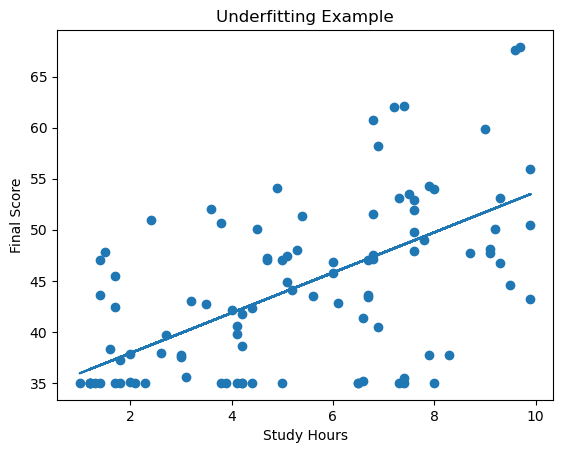

In [19]:
plt.scatter(X_test, y_test)
plt.plot(X_test, test_pred)
plt.xlabel("Study Hours")
plt.ylabel("Final Score")
plt.title("Underfitting Example")
plt.show()

**Explanation**

- The model is very simple and may miss important patterns.
- Training and test errors can both be high.
- This is an example of Underfitting.

## **2. Good Fit**

**Understand the Concept**

- A Good Fit means the model learns the important patterns in the data.
- It performs well on both training and unseen data.
- Training and validation errors are reasonably low and close.

**Example**

- A model learns the main pattern without being too simple.
- The model gives similar performance on training and test data.

## **3. Overfitting**

**Understand the Concept**

- Overfitting happens when a model is too complex.
- The model learns the training data too closely, including noise.
- Training error is very low, but test error is high.

**Example**

- A high-degree polynomial can fit the training data very closely.
- It may perform poorly on new data.

In [20]:
# High complexity model
poly = PolynomialFeatures(degree=10)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model = LinearRegression()
model.fit(X_train_poly, y_train)

train_pred = model.predict(X_train_poly)
test_pred = model.predict(X_test_poly)

train_error = mean_squared_error(y_train, train_pred)
test_error = mean_squared_error(y_test, test_pred)

print("Training Error:", train_error)
print("Test Error:", test_error)



Training Error: 46.552913460449545
Test Error: 48.20142987640644


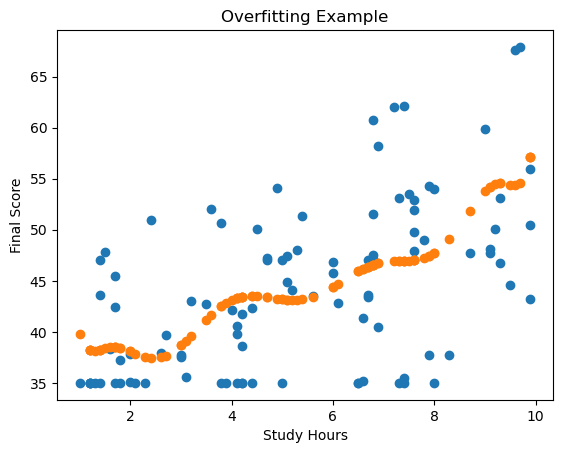

In [21]:
plt.scatter(X_test, y_test)
plt.scatter(X_test, test_pred)
plt.xlabel("Study Hours")
plt.ylabel("Final Score")
plt.title("Overfitting Example")
plt.show()

**Explanation**

- The model is too complex and learns the training data closely.
- Training error is low, but test error can be much higher.
- This is an example of Overfitting.

## **4. Bias**

**Understand the Concept**

- Bias is the error caused by a model being too simple.
- High bias can lead to Underfitting.
- The model may miss important patterns.

**Example**

- A simple model cannot learn a complex relationship.
- It gives similar but inaccurate predictions.

In [22]:
# High Bias Example
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("Training Error:", mean_squared_error(y_train, train_pred))
print("Test Error:", mean_squared_error(y_test, test_pred))

Training Error: 48.60246275122765
Test Error: 46.406330060859545


**Explanation**

- High bias means the model is too simple.
- It can cause Underfitting.

## **5. Variance**

**Understand the Concept**

- Variance shows how much a model changes with different training data.
- High variance means the model learns the training data too closely.
- High variance can lead to Overfitting.

**Example**

- A complex model fits training data very closely.
- Its performance changes a lot on new data.

## **6. Bias-Variance Tradeoff**

**Understand the Concept**

- Bias and Variance are two types of model error.
- Simple models usually have higher Bias.
- Complex models usually have higher Variance.
- We try to find a balance between them.

**Example**

- Too simple → High Bias → Underfitting.
- Too complex → High Variance → Overfitting.

## **7. Training Error**

**Understand the Concept**

- Training Error measures the model's mistakes on training data.
- Lower training error means the model fits the training data better.
- Very low training error can sometimes indicate Overfitting.

**Formula**

Training Error = Error between actual and predicted training values

**Example**

- The model predicts the training data.
- The difference between actual and predicted values is measured.

In [23]:
train_error = mean_squared_error(y_train, train_pred)
print("Training Error:", train_error)

Training Error: 48.60246275122765


**Explanation**

- Training Error shows how well the model fits training data.
- Very low error does not always mean a good model.

## **8. Validation Error**

**Understand the Concept**

- Validation Error measures model performance on validation data.
- It helps us choose and tune the model.
- A large difference between training and validation error can indicate Overfitting.

**Example**

- Train the model using training data.
- Use validation data to check its performance.

In [24]:

X_train, X_validation, y_train, y_validation = train_test_split(X,y,test_size=0.2,random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

validation_pred = model.predict(X_validation)

validation_error = mean_squared_error(y_validation,validation_pred)
print("Validation Error:", validation_error)

Validation Error: 46.406330060859545


**Explanation**

- Validation Error shows how the model performs on unseen validation data.
- It helps compare and tune models.

## **9. Test Error**

**Understand the Concept**

- Test Error measures model performance on completely unseen data.
- It gives an idea of how the final model may perform on new data.
- The test data should not be used for model tuning.

**Example**

- Train and tune the model using training and validation data.
- Use test data only for the final evaluation.

In [25]:
model = LinearRegression()
model.fit(X_train, y_train)

test_pred = model.predict(X_test)
test_error = mean_squared_error(y_test, test_pred)
print("Test Error:", test_error)

Test Error: 46.406330060859545


## **10. Model Complexity**

**Understand the Concept**

- Model Complexity describes how simple or complex a model is.
- A simple model may Underfit.
- A very complex model may Overfit.
- We need a suitable level of complexity.

**Example**

- Degree 1 polynomial is simple.
- Degree 10 polynomial is more complex.

In [26]:
degrees = [1, 2, 5, 10]

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    train_pred = model.predict(X_train_poly)
    test_pred = model.predict(X_test_poly)

    print("Degree:", degree,
          "Training Error:", mean_squared_error(y_train, train_pred),
          "Test Error:", mean_squared_error(y_test, test_pred))

Degree: 1 Training Error: 48.602462751227655 Test Error: 46.406330060859545
Degree: 2 Training Error: 47.65575352360233 Test Error: 46.163023307005275
Degree: 5 Training Error: 47.06851123565153 Test Error: 46.62159889313751
Degree: 10 Training Error: 46.552913460449545 Test Error: 48.20142987640644


**Explanation**

- Increasing complexity can reduce training error.
- Very high complexity can increase test error.
- The goal is to find a suitable complexity.

## **11. Regularization – Introduction**

**Understand the Concept**

- Regularization helps reduce Overfitting.
- It adds a penalty to large model coefficients.
- It encourages the model to stay simpler.

**How It Works**

- The model tries to fit the data.
- A penalty is added for large coefficients.
- This helps control model complexity.

**Example**

- Linear Regression can fit the training data closely.
- Regularization can help make the model more stable on new data.

In [27]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("Training Error:", mean_squared_error(y_train, train_pred))
print("Test Error:", mean_squared_error(y_test, test_pred))

Training Error: 48.6024660825906
Test Error: 46.40390521967298


**Explanation**

- Ridge Regression adds regularization to the model.
- alpha controls the strength of the penalty.
- Regularization helps reduce Overfitting.